### Graz Results

In [1]:
import os
from sqlalchemy import create_engine
db_url = (
    f"postgresql://{os.getenv('POSTGRES_USER')}:"
    f"{os.getenv('POSTGRES_PASSWORD')}@"
    f"localhost:5432/"
    f"{os.getenv('POSTGRES_DB')}"
)

engine = create_engine(db_url)

In [2]:
%load_ext autoreload
%autoreload 2
from prepare_graz_validation import add_station_dataset
import pandas as pd

path_stations_count = "/home/jmartinez/Documents/bike_project/src/python/src/bike_project/validation/stations_datasets/processed/graz_stations_count.csv"
path_stations_ref = "/home/jmartinez/Documents/bike_project/src/python/src/bike_project/validation/stations_datasets/processed/graz_stations_ref.json"

input_query = "SELECT * FROM temp_hubs_final_graz_no_zones"
add_station_dataset(input_query,counting_stations_count_path=path_stations_count,counting_stations_ref_path=path_stations_ref,
                    counting_stations_count_table="counting_stations_count",counting_stations_ref_table="counting_stations_ref", 
                    city_name = 'Graz')
query = """SELECT * FROM counting_stations_count WHERE fetched_city = 'Graz'"""
graz_df = pd.read_sql(query,engine)
graz_df["date"] = pd.to_datetime(graz_df["time"]).dt.date
daily_df = graz_df[["id","date","count","count_sim"]].groupby(["id","date","count_sim"],as_index=False).sum()
num_days_df = daily_df[["id","date"]].groupby(["id"],as_index=False).count().rename(columns={"date":"num_days"})
total_count_df = daily_df[["id","count","count_sim"]].groupby(["id","count_sim"],as_index=False).sum()
average_daily_df_base = pd.merge(total_count_df,num_days_df)
average_daily_df_base = average_daily_df_base.rename(columns={"count_sim": "count_base"})
average_daily_df_base["count_aadt"] = average_daily_df_base["count"] / average_daily_df_base["num_days"]
average_daily_df_base 

,id,count_base,count,num_days,count_aadt
0,GRZ_102,5500,4.363644e+05,267,1634.323467
1,GRZ_103,1499,2.530088e+05,362,698.919419
2,GRZ_1091,7170,4.146141e+04,28,1480.764537
3,GRZ_1092,803,3.607671e+05,365,988.402904
4,GRZ_1116,3063,1.856256e+05,313,593.053149
5,GRZ_1152,164,1.442596e+05,366,394.151798
6,GRZ_390,2322,3.505091e+05,366,957.675031
7,GRZ_501,6008,6.288633e+05,366,1718.205615
8,GRZ_558,6771,2.951030e+06,366,8062.923561
9,GRZ_569,3713,7.661069e+05,364,2104.689173


In [3]:
import geopandas as gpd

count_df = pd.read_sql(query,engine)
df_ref = gpd.GeoDataFrame.from_file(path_stations_ref)
df_ref

,id,fetched_city,geometry
0,GRZ_1091,Graz,POINT (15.43509 47.07279)
1,GRZ_1092,Graz,POINT (15.41417 47.10408)
2,GRZ_922,Graz,POINT (15.41218 47.06368)
3,GRZ_922,Graz,POINT (15.41252 47.06369)
4,GRZ_390,Graz,POINT (15.42252 47.09412)
5,GRZ_569,Graz,POINT (15.45899 47.06149)
6,GRZ_1116,Graz,POINT (15.40279 47.07064)
7,GRZ_905,Graz,POINT (15.40899 47.06996)
8,GRZ_905,Graz,POINT (15.40944 47.06982)
9,GRZ_905,Graz,POINT (15.40948 47.06995)


In [4]:
ref_merged_df = df_ref.merge(count_df["id"], on="id", how="inner").drop_duplicates()
ref_merged_df

,id,fetched_city,geometry
0,GRZ_1091,Graz,POINT (15.43509 47.07279)
418,GRZ_1092,Graz,POINT (15.41417 47.10408)
8098,GRZ_922,Graz,POINT (15.41218 47.06368)
14994,GRZ_922,Graz,POINT (15.41252 47.06369)
21890,GRZ_390,Graz,POINT (15.42252 47.09412)
30104,GRZ_569,Graz,POINT (15.45899 47.06149)
38726,GRZ_1116,Graz,POINT (15.40279 47.07064)
45475,GRZ_905,Graz,POINT (15.40899 47.06996)
52914,GRZ_905,Graz,POINT (15.40944 47.06982)
60353,GRZ_905,Graz,POINT (15.40948 47.06995)


In [5]:
ref_merged_df.to_postgis("real_graz_stations",engine)

ValueError: Table 'real_graz_stations' already exists.

In [7]:
input_query = "SELECT * FROM results_graz_base_pois"
add_station_dataset(input_query,counting_stations_count_path=path_stations_count,counting_stations_ref_path=path_stations_ref,
                    counting_stations_count_table="counting_stations_count",counting_stations_ref_table="counting_stations_ref", 
                    city_name = 'Graz')
query = """SELECT * FROM counting_stations_count WHERE fetched_city = 'Graz'"""
graz_df = pd.read_sql(query,engine)
graz_df["date"] = pd.to_datetime(graz_df["time"]).dt.date
daily_df = graz_df[["id","date","count","count_sim"]].groupby(["id","date","count_sim"],as_index=False).sum()
num_days_df = daily_df[["id","date"]].groupby(["id"],as_index=False).count().rename(columns={"date":"num_days"})
total_count_df = daily_df[["id","count","count_sim"]].groupby(["id","count_sim"],as_index=False).sum()
average_daily_df_base_pois = pd.merge(total_count_df,num_days_df)
average_daily_df_base_pois = average_daily_df_base_pois.rename(columns={"count_sim": "count_base_pois"})
average_daily_df_base_pois["count_aadt"] = average_daily_df_base_pois["count"] / average_daily_df_base_pois["num_days"]
average_daily_df_base_pois 

,id,count_base_pois,count,num_days,count_aadt
0,GRZ_102,6532,4.363644e+05,267,1634.323467
1,GRZ_103,2474,2.530088e+05,362,698.919419
2,GRZ_1091,7200,4.146141e+04,28,1480.764537
3,GRZ_1092,1508,3.607671e+05,365,988.402904
4,GRZ_1116,2276,1.856256e+05,313,593.053149
5,GRZ_1152,297,1.442596e+05,366,394.151798
6,GRZ_390,2408,3.505091e+05,366,957.675031
7,GRZ_501,5814,6.288633e+05,366,1718.205615
8,GRZ_558,9419,2.951030e+06,366,8062.923561
9,GRZ_569,4407,7.661069e+05,364,2104.689173


In [8]:
input_query = "SELECT * FROM results_graz_base_non_random_des"
add_station_dataset(input_query,counting_stations_count_path=path_stations_count,counting_stations_ref_path=path_stations_ref,
                    counting_stations_count_table="counting_stations_count",counting_stations_ref_table="counting_stations_ref", 
                    city_name = 'Graz')
query = """SELECT * FROM counting_stations_count WHERE fetched_city = 'Graz'"""
graz_df = pd.read_sql(query,engine)
graz_df["date"] = pd.to_datetime(graz_df["time"]).dt.date
daily_df = graz_df[["id","date","count","count_sim"]].groupby(["id","date","count_sim"],as_index=False).sum()
num_days_df = daily_df[["id","date"]].groupby(["id"],as_index=False).count().rename(columns={"date":"num_days"})
total_count_df = daily_df[["id","count","count_sim"]].groupby(["id","count_sim"],as_index=False).sum()
average_daily_df_base_nrd = pd.merge(total_count_df,num_days_df)
average_daily_df_base_nrd = average_daily_df_base_nrd.rename(columns={"count_sim": "count_base_nrd"})
average_daily_df_base_nrd["count_aadt"] = average_daily_df_base_nrd["count"] / average_daily_df_base_nrd["num_days"]
average_daily_df_base_nrd 

,id,count_base_nrd,count,num_days,count_aadt
0,GRZ_102,13083,4.363644e+05,267,1634.323467
1,GRZ_103,3165,2.530088e+05,362,698.919419
2,GRZ_1091,12049,4.146141e+04,28,1480.764537
3,GRZ_1092,2409,3.607671e+05,365,988.402904
4,GRZ_1116,5604,1.856256e+05,313,593.053149
5,GRZ_1152,508,1.442596e+05,366,394.151798
6,GRZ_390,4820,3.505091e+05,366,957.675031
7,GRZ_501,9887,6.288633e+05,366,1718.205615
8,GRZ_558,14877,2.951030e+06,366,8062.923561
9,GRZ_569,8960,7.661069e+05,364,2104.689173


In [9]:
input_query = "SELECT * FROM results_graz_base_dist"
add_station_dataset(input_query,counting_stations_count_path=path_stations_count,counting_stations_ref_path=path_stations_ref,
                    counting_stations_count_table="counting_stations_count",counting_stations_ref_table="counting_stations_ref", 
                    city_name = 'Graz')
query = """SELECT * FROM counting_stations_count WHERE fetched_city = 'Graz'"""
graz_df = pd.read_sql(query,engine)
graz_df["date"] = pd.to_datetime(graz_df["time"]).dt.date
daily_df = graz_df[["id","date","count","count_sim"]].groupby(["id","date","count_sim"],as_index=False).sum()
num_days_df = daily_df[["id","date"]].groupby(["id"],as_index=False).count().rename(columns={"date":"num_days"})
total_count_df = daily_df[["id","count","count_sim"]].groupby(["id","count_sim"],as_index=False).sum()
average_daily_df_base_dist = pd.merge(total_count_df,num_days_df)
average_daily_df_base_dist = average_daily_df_base_dist.rename(columns={"count_sim": "count_base_dist"})
average_daily_df_base_dist["count_aadt"] = average_daily_df_base_dist["count"] / average_daily_df_base_dist["num_days"]
average_daily_df_base_dist 

,id,count_base_dist,count,num_days,count_aadt
0,GRZ_102,12047,4.363644e+05,267,1634.323467
1,GRZ_103,3525,2.530088e+05,362,698.919419
2,GRZ_1091,8371,4.146141e+04,28,1480.764537
3,GRZ_1092,1663,3.607671e+05,365,988.402904
4,GRZ_1116,4637,1.856256e+05,313,593.053149
5,GRZ_1152,639,1.442596e+05,366,394.151798
6,GRZ_390,3286,3.505091e+05,366,957.675031
7,GRZ_501,5989,6.288633e+05,366,1718.205615
8,GRZ_558,12957,2.951030e+06,366,8062.923561
9,GRZ_569,6882,7.661069e+05,364,2104.689173


In [10]:
input_query = "SELECT * FROM results_graz_final"
add_station_dataset(input_query,counting_stations_count_path=path_stations_count,counting_stations_ref_path=path_stations_ref,
                    counting_stations_count_table="counting_stations_count",counting_stations_ref_table="counting_stations_ref", 
                    city_name = 'Graz')
query = """SELECT * FROM counting_stations_count WHERE fetched_city = 'Graz'"""
graz_df = pd.read_sql(query,engine)
graz_df["date"] = pd.to_datetime(graz_df["time"]).dt.date
daily_df = graz_df[["id","date","count","count_sim"]].groupby(["id","date","count_sim"],as_index=False).sum()
num_days_df = daily_df[["id","date"]].groupby(["id"],as_index=False).count().rename(columns={"date":"num_days"})
total_count_df = daily_df[["id","count","count_sim"]].groupby(["id","count_sim"],as_index=False).sum()
average_daily_df_final= pd.merge(total_count_df,num_days_df)
average_daily_df_final["count_aadt"] = average_daily_df_final["count"] / average_daily_df_final["num_days"]
average_daily_df_final 

,id,count_sim,count,num_days,count_aadt
0,GRZ_102,8580,4.363644e+05,267,1634.323467
1,GRZ_103,3920,2.530088e+05,362,698.919419
2,GRZ_1091,7219,4.146141e+04,28,1480.764537
3,GRZ_1092,1299,3.607671e+05,365,988.402904
4,GRZ_1116,3387,1.856256e+05,313,593.053149
5,GRZ_1152,600,1.442596e+05,366,394.151798
6,GRZ_390,3293,3.505091e+05,366,957.675031
7,GRZ_501,4569,6.288633e+05,366,1718.205615
8,GRZ_558,13008,2.951030e+06,366,8062.923561
9,GRZ_569,6140,7.661069e+05,364,2104.689173


In [11]:
from functools import reduce

list_df = [average_daily_df_base, average_daily_df_base_pois, average_daily_df_base_nrd, average_daily_df_base_dist, average_daily_df_final]

graz_df_raw = pd.concat(list_df, axis=1).T.drop_duplicates().T
graz_df_raw

,id,count_base,count,num_days,count_aadt,count_base_pois,count_base_nrd,count_base_dist,count_sim
0,GRZ_102,5500,436364.365681,267,1634.323467,6532,13083,12047,8580
1,GRZ_103,1499,253008.8296,362,698.919419,2474,3165,3525,3920
2,GRZ_1091,7170,41461.407047,28,1480.764537,7200,12049,8371,7219
3,GRZ_1092,803,360767.059986,365,988.402904,1508,2409,1663,1299
4,GRZ_1116,3063,185625.63577,313,593.053149,2276,5604,4637,3387
5,GRZ_1152,164,144259.558099,366,394.151798,297,508,639,600
6,GRZ_390,2322,350509.061483,366,957.675031,2408,4820,3286,3293
7,GRZ_501,6008,628863.254952,366,1718.205615,5814,9887,5989,4569
8,GRZ_558,6771,2951030.023193,366,8062.923561,9419,14877,12957,13008
9,GRZ_569,3713,766106.85897,364,2104.689173,4407,8960,6882,6140


In [12]:
graz_df = graz_df_raw[~graz_df_raw["id"].isin(["GRZ_749"])]
graz_df

,id,count_base,count,num_days,count_aadt,count_base_pois,count_base_nrd,count_base_dist,count_sim
0,GRZ_102,5500,436364.365681,267,1634.323467,6532,13083,12047,8580
1,GRZ_103,1499,253008.8296,362,698.919419,2474,3165,3525,3920
2,GRZ_1091,7170,41461.407047,28,1480.764537,7200,12049,8371,7219
3,GRZ_1092,803,360767.059986,365,988.402904,1508,2409,1663,1299
4,GRZ_1116,3063,185625.63577,313,593.053149,2276,5604,4637,3387
5,GRZ_1152,164,144259.558099,366,394.151798,297,508,639,600
6,GRZ_390,2322,350509.061483,366,957.675031,2408,4820,3286,3293
7,GRZ_501,6008,628863.254952,366,1718.205615,5814,9887,5989,4569
8,GRZ_558,6771,2951030.023193,366,8062.923561,9419,14877,12957,13008
9,GRZ_569,3713,766106.85897,364,2104.689173,4407,8960,6882,6140


In [13]:
graz_df["count_aadt"] = graz_df["count_aadt"].astype(float)
graz_df["count_base"] = graz_df["count_base"].astype(float)
graz_df["count_base_pois"] = graz_df["count_base_pois"].astype(float)
graz_df["count_base_nrd"] = graz_df["count_base_nrd"].astype(float)
graz_df["count_base_dist"] = graz_df["count_base_dist"].astype(float)
graz_df["count_sim"] = graz_df["count_sim"].astype(float)


In [14]:
graz_df["rank"] = graz_df["count_aadt"].rank(ascending=False)
graz_df["rank_base"] = graz_df["count_base"].rank(ascending=False)
graz_df["rank_base_pois"] = graz_df["count_base_pois"].rank(ascending=False)
graz_df["rank_base_nrd"] = graz_df["count_base_nrd"].rank(ascending=False)
graz_df["rank_base_dist"] = graz_df["count_base_dist"].rank(ascending=False)

graz_df["rank_sim"] = graz_df["count_sim"].rank(ascending=False)
graz_df

,id,count_base,count,num_days,count_aadt,count_base_pois,count_base_nrd,count_base_dist,count_sim,rank,rank_base,rank_base_pois,rank_base_nrd,rank_base_dist,rank_sim
0,GRZ_102,5500.0,436364.365681,267,1634.323467,6532.0,13083.0,12047.0,8580.0,5.0,5.0,4.0,3.0,3.0,3.0
1,GRZ_103,1499.0,253008.8296,362,698.919419,2474.0,3165.0,3525.0,3920.0,9.0,10.0,7.0,10.0,8.0,7.0
2,GRZ_1091,7170.0,41461.407047,28,1480.764537,7200.0,12049.0,8371.0,7219.0,6.0,2.0,3.0,4.0,4.0,4.0
3,GRZ_1092,803.0,360767.059986,365,988.402904,1508.0,2409.0,1663.0,1299.0,7.0,11.0,11.0,11.0,11.0,11.0
4,GRZ_1116,3063.0,185625.63577,313,593.053149,2276.0,5604.0,4637.0,3387.0,10.0,8.0,9.0,7.0,7.0,8.0
5,GRZ_1152,164.0,144259.558099,366,394.151798,297.0,508.0,639.0,600.0,11.0,12.0,12.0,12.0,12.0,12.0
6,GRZ_390,2322.0,350509.061483,366,957.675031,2408.0,4820.0,3286.0,3293.0,8.0,9.0,8.0,8.0,10.0,9.0
7,GRZ_501,6008.0,628863.254952,366,1718.205615,5814.0,9887.0,5989.0,4569.0,4.0,4.0,5.0,5.0,6.0,6.0
8,GRZ_558,6771.0,2951030.023193,366,8062.923561,9419.0,14877.0,12957.0,13008.0,1.0,3.0,1.0,2.0,2.0,2.0
9,GRZ_569,3713.0,766106.85897,364,2104.689173,4407.0,8960.0,6882.0,6140.0,3.0,6.0,6.0,6.0,5.0,5.0


In [15]:
graz_df[["count_aadt","count_base","count_base_pois","count_base_nrd",
         "count_base_dist","count_sim"]].corr(method="kendall")

,count_aadt,count_base,count_base_pois,count_base_nrd,count_base_dist,count_sim
count_aadt,1.000000,0.484848,0.636364,0.575758,0.575758,0.636364
count_base,0.484848,1.000000,0.727273,0.848485,0.787879,0.727273
count_base_pois,0.636364,0.727273,1.000000,0.818182,0.818182,0.878788
count_base_nrd,0.575758,0.848485,0.818182,1.000000,0.878788,0.878788
count_base_dist,0.575758,0.787879,0.818182,0.878788,1.000000,0.939394
count_sim,0.636364,0.727273,0.878788,0.878788,0.939394,1.000000


In [16]:
from scipy.stats import pearsonr

res = pearsonr(graz_df["count_aadt"], graz_df["count_sim"])

print("Pearson correlation:", res.statistic)
print("p-value:", res.pvalue)

Pearson correlation: 0.872738754474632
p-value: 0.00021150451316839664


In [17]:
graz_df[["rank","rank_base","rank_base_pois","rank_base_nrd",
         "rank_base_dist","rank_sim"]].corr(method="kendall")

,rank,rank_base,rank_base_pois,rank_base_nrd,rank_base_dist,rank_sim
rank,1.000000,0.484848,0.636364,0.575758,0.575758,0.636364
rank_base,0.484848,1.000000,0.727273,0.848485,0.787879,0.727273
rank_base_pois,0.636364,0.727273,1.000000,0.818182,0.818182,0.878788
rank_base_nrd,0.575758,0.848485,0.818182,1.000000,0.878788,0.878788
rank_base_dist,0.575758,0.787879,0.818182,0.878788,1.000000,0.939394
rank_sim,0.636364,0.727273,0.878788,0.878788,0.939394,1.000000


P-values
rank_base         0.007355
rank_base_pois    0.000643
rank_base_nrd     0.001615
rank_base_dist    0.001900
rank_sim          0.000785
Name: rank, dtype: float64


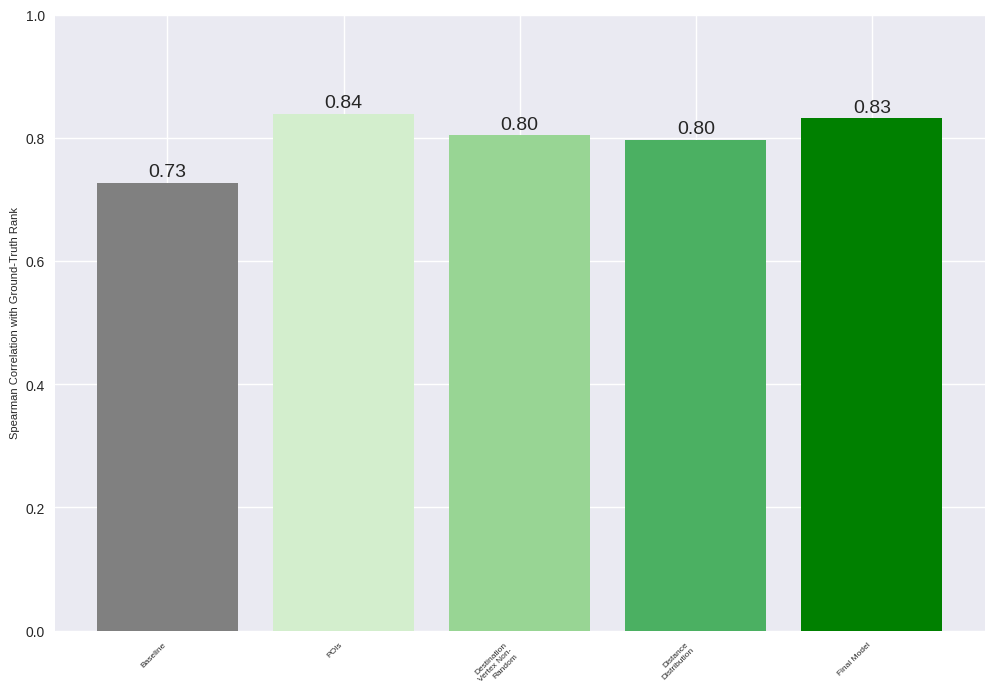

In [18]:
import seaborn as sns
import textwrap
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import spearmanr, kendalltau, pearsonr

plt.figure(figsize=(12, 8))

plt.style.use('seaborn-v0_8')

corrs = (
    graz_df[["rank", "rank_base", "rank_base_pois","rank_base_nrd","rank_base_dist","rank_sim"]]
    .corr()["rank"]
    .drop("rank")
)

rank_df = graz_df[["rank", "rank_base", "rank_base_pois","rank_base_nrd","rank_base_dist","rank_sim"]]

corrs = (
    rank_df
    .corr()["rank"]
    .drop("rank")
)


corr_matrix, p_matrix = spearmanr(rank_df)


pval_df = pd.DataFrame(p_matrix,
                       index=rank_df.columns,
                       columns=rank_df.columns)
print("P-values")
print(pval_df["rank"]
    .drop("rank"))


labels = ["Baseline", "POIs", "Destination Vertex Non-Random","Distance Distribution","Final Model"]
wrapped_labels = [textwrap.fill(label, 14) for label in labels]

middle_colors = plt.cm.Greens(np.linspace(0.2, 0.6, 3))

colors = (
    ["gray"] +                    
    list(middle_colors) +         
    ["green", "#6D3B07", "#EC1B2D"]    
)
plt.bar(
    x=wrapped_labels,
    height=corrs.values, color=colors)

for i, v in enumerate(corrs.values):
    plt.text(i, v + 0.01, f"{v:.2f}", ha="center",fontsize=14)

plt.ylim(0, 1)
plt.ylabel("Spearman Correlation with Ground-Truth Rank", fontsize = 8)
# plt.xlabel("Method")
plt.xticks(rotation=45, ha="right", fontsize=6)

plt.savefig("figures/graz_spearman")

import tikzplotlib

# plt.tight_layout()

tikzplotlib.save("figures/graz_spearman.tex")

rank_base         0.031050
rank_base_pois    0.003182
rank_base_nrd     0.008758
rank_base_dist    0.008758
rank_sim          0.003182
Name: rank, dtype: float64


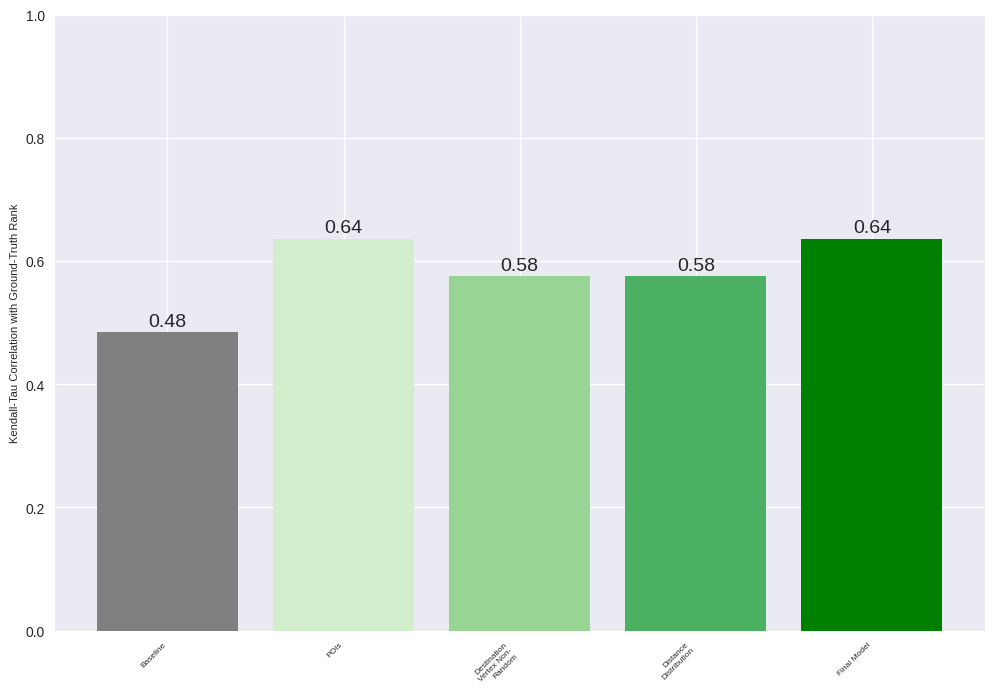

In [19]:
import seaborn as sns
import textwrap
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(12, 8))

plt.style.use('seaborn-v0_8')

corrs = (
    graz_df[["rank", "rank_base", "rank_base_pois","rank_base_nrd","rank_base_dist","rank_sim"]]
    .corr(method="kendall")["rank"]
    .drop("rank")
)

rank_df = graz_df[["rank", "rank_base", "rank_base_pois","rank_base_nrd","rank_base_dist","rank_sim"]]


cols = rank_df.columns

corr_matrix = pd.DataFrame(index=cols, columns=cols, dtype=float)
p_matrix = pd.DataFrame(index=cols, columns=cols, dtype=float)

for c1 in cols:
    for c2 in cols:
        tau, pval = kendalltau(rank_df[c1], rank_df[c2])

        corr_matrix.loc[c1, c2] = tau
        p_matrix.loc[c1, c2] = pval

pval_df = pd.DataFrame(p_matrix, index=cols,columns=cols)



print(pval_df["rank"]
    .drop("rank"))


labels = ["Baseline", "POIs", "Destination Vertex Non-Random","Distance Distribution","Final Model"]
wrapped_labels = [textwrap.fill(label, 14) for label in labels]

middle_colors = plt.cm.Greens(np.linspace(0.2, 0.6, 3))

colors = (
    ["gray"] +                    
    list(middle_colors) +         
    ["green", "#6D3B07", "#EC1B2D"]    
)
plt.bar(
    x=wrapped_labels,
    height=corrs.values, color=colors)

for i, v in enumerate(corrs.values):
    plt.text(i, v + 0.01, f"{v:.2f}", ha="center",fontsize=14)

plt.ylim(0, 1)
plt.ylabel("Kendall-Tau Correlation with Ground-Truth Rank", fontsize = 8)
# plt.xlabel("Method")
plt.xticks(rotation=45, ha="right", fontsize=6)

plt.savefig("figures/graz_kendalltau")

import tikzplotlib


tikzplotlib.save("figures/graz_kendalltau.tex")

count_base         0.015243
count_base_pois    0.001075
count_base_nrd     0.003506
count_base_dist    0.002274
count_sim          0.000212
Name: count_aadt, dtype: float64


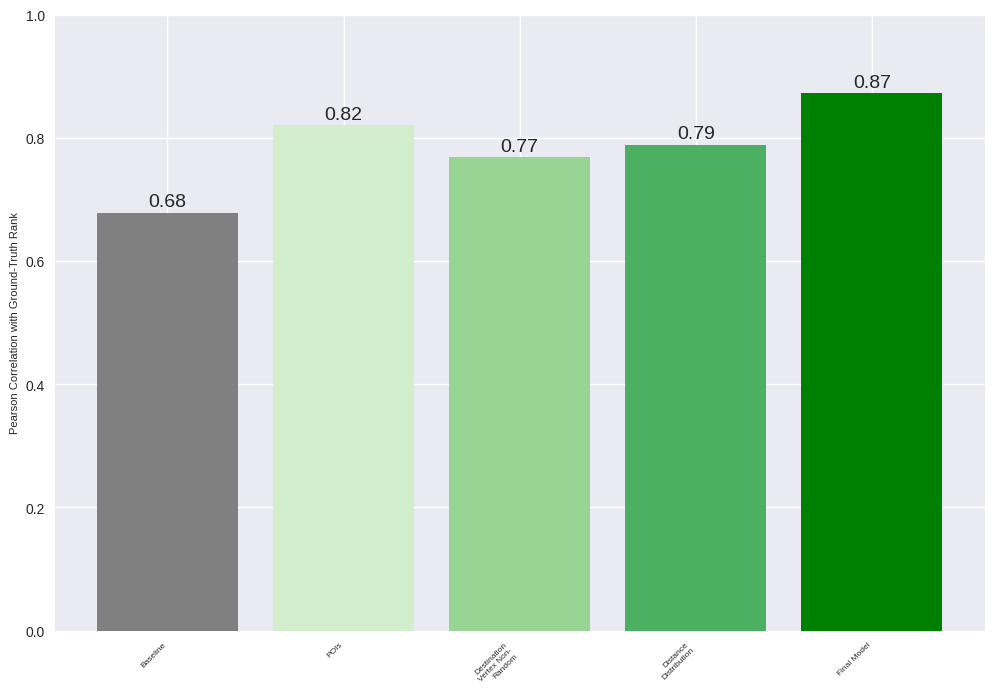

In [20]:
import seaborn as sns
import textwrap
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(12, 8))

plt.style.use('seaborn-v0_8')

corrs = (
    graz_df[["count_aadt", "count_base", "count_base_pois","count_base_nrd","count_base_dist","count_sim"]]
    .corr(method="pearson")["count_aadt"]
    .drop("count_aadt")
)

count_df = graz_df[["count_aadt", "count_base", "count_base_pois","count_base_nrd","count_base_dist","count_sim"]]


cols = count_df.columns

corr_matrix = pd.DataFrame(index=cols, columns=cols, dtype=float)
p_matrix = pd.DataFrame(index=cols, columns=cols, dtype=float)

for c1 in cols:
    for c2 in cols:
        tau, pval = pearsonr(count_df[c1], count_df[c2])

        corr_matrix.loc[c1, c2] = tau
        p_matrix.loc[c1, c2] = pval

pval_df = pd.DataFrame(p_matrix, index=cols,columns=cols)



print(pval_df["count_aadt"]
    .drop("count_aadt"))

labels = ["Baseline", "POIs", "Destination Vertex Non-Random","Distance Distribution","Final Model"]
wrapped_labels = [textwrap.fill(label, 14) for label in labels]

middle_colors = plt.cm.Greens(np.linspace(0.2, 0.6, 3))

colors = (
    ["gray"] +                    
    list(middle_colors) +         
    ["green", "#6D3B07", "#EC1B2D"]    
)
plt.bar(
    x=wrapped_labels,
    height=corrs.values, color=colors)

for i, v in enumerate(corrs.values):
    plt.text(i, v + 0.01, f"{v:.2f}", ha="center",fontsize=14)

plt.ylim(0, 1)
plt.ylabel("Pearson Correlation with Ground-Truth Rank", fontsize = 8)
# plt.xlabel("Method")
plt.xticks(rotation=45, ha="right", fontsize=6)

plt.savefig("figures/graz_pearson")

import tikzplotlib

tikzplotlib.save("figures/graz_pearson.tex")